# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/balabhadra3141/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

# Google Search Ranking & Discoverability Capstone

## Refresh Opportunity Scoring: A Decision-Support Ranking for Content Review

This capstone studies whether February search-performance signals can help prioritize pages for human review when the following month's search activity contains a zero-click outcome.

The work treats the output as a ranking and decision-support system rather than an automated content-editing system. The final feature set uses only information available in the February decision window: impressions, clicks, and average position.

The analysis compares a transparent Week-4 rule-based baseline with Logistic Regression using the same data, target, split, and Precision@K metrics.

In [1]:
import os
import json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import userdata

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score

# ---------------------------------------------------------
# Hugging Face authentication
# ---------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN was not found. "
        "Add your Hugging Face READ token as a Colab Secret named 'HF_TOKEN'."
    )

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
DIM_CONTENT = f"{REL}/dim_content.parquet"

FEB = f"read_parquet('{FACT}/month=2026-02/*.parquet')"
MAR = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

print("Connected to FlyRank warehouse.")
print("Feature window: February 2026")
print("Outcome window: March 2026")

Connected to FlyRank warehouse.
Feature window: February 2026
Outcome window: March 2026


## 1. Question

### Research question

Can February search-performance signals be used to rank published content pages by their observed likelihood of having zero clicks in March, so that a content team can decide which pages to review first?

### Decision supported

The output supports one operational decision:

> Which pages should receive earlier human review when review capacity is limited?

### Action

A high-ranked page enters the review queue earlier. The score does not determine the final content action.

A reviewer can inspect search intent, page relevance, indexing, technical issues, seasonality, and content quality before deciding whether to update, monitor, or leave the page unchanged.

### Lane

**Refresh / Content Opportunity Scoring**

The problem is treated as a ranking/prioritization problem with a binary March outcome used for model training and evaluation.

## 1. Question

### Research question

Can February search-performance signals be used to rank published content pages by their observed likelihood of having zero clicks in March, so that a content team can decide which pages to review first?

### Decision supported

The output supports one operational decision:

> Which pages should receive earlier human review when review capacity is limited?

### Action

A high-ranked page enters the review queue earlier. The score does not determine the final content action.

A reviewer can inspect search intent, page relevance, indexing, technical issues, seasonality, and content quality before deciding whether to update, monitor, or leave the page unchanged.

### Lane

**Refresh / Content Opportunity Scoring**

The problem is treated as a ranking/prioritization problem with a binary March outcome used for model training and evaluation.

In [2]:
# build final modeling dataset
model_df = con.sql(
    f"""
    WITH feb AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(gsc_impressions) FILTER (
                WHERE gsc_data_available IS TRUE
            ) AS impressions_feb,

            SUM(gsc_clicks) FILTER (
                WHERE gsc_data_available IS TRUE
            ) AS clicks_feb,

            CASE
                WHEN SUM(gsc_impressions) FILTER (
                    WHERE gsc_data_available IS TRUE
                ) > 0
                THEN
                    CAST(
                        SUM(gsc_sum_position) FILTER (
                            WHERE gsc_data_available IS TRUE
                        ) AS DOUBLE
                    )
                    /
                    SUM(gsc_impressions) FILTER (
                        WHERE gsc_data_available IS TRUE
                    )
                ELSE NULL
            END AS avg_position_feb

        FROM {FEB}

        GROUP BY
            client_hash_id,
            content_hash_id
    ),

    mar AS (
        SELECT
            client_hash_id,
            content_hash_id,

            SUM(gsc_clicks) FILTER (
                WHERE gsc_data_available IS TRUE
            ) AS clicks_mar,

            COUNT(*) FILTER (
                WHERE gsc_data_available IS TRUE
            ) AS available_days_mar

        FROM {MAR}

        GROUP BY
            client_hash_id,
            content_hash_id
    )

    SELECT
        f.client_hash_id,
        f.content_hash_id,
        f.impressions_feb,
        f.clicks_feb,
        f.avg_position_feb,
        m.clicks_mar,
        m.available_days_mar,

        CASE
            WHEN m.available_days_mar > 0
                 AND COALESCE(m.clicks_mar, 0) = 0
            THEN 1
            ELSE 0
        END AS march_zero_click

    FROM feb f

    JOIN '{DIM_CONTENT}' c
        ON f.content_hash_id = c.content_hash_id

    JOIN mar m
        ON f.client_hash_id = m.client_hash_id
        AND f.content_hash_id = m.content_hash_id

    WHERE
        f.impressions_feb >= 100
        AND f.clicks_feb >= 3
        AND f.avg_position_feb IS NOT NULL
        AND c.is_published IS TRUE
    """
).df()

print("Modeling rows:", len(model_df))
display(model_df.head())

Modeling rows: 29362


,client_hash_id,content_hash_id,impressions_feb,clicks_feb,avg_position_feb,clicks_mar,available_days_mar,march_zero_click
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,4270.0,7.0,5.960187,7.0,31,0
1,client_73cda7b4e4f265ea,content_36c36abc7650d7af,5271.0,4.0,7.125783,6.0,31,0
2,client_73cda7b4e4f265ea,content_a7da352b73b02668,6690.0,19.0,7.226756,13.0,31,0
3,client_73cda7b4e4f265ea,content_aafb2ab7e5fc80d0,4314.0,14.0,6.424200,20.0,31,0
4,client_73cda7b4e4f265ea,content_20403327d8d9374c,2756.0,8.0,6.726415,10.0,31,0


## 3. Methodology

### Unit of analysis

One row represents one client-content page pair with February search signals and a March outcome.

### Features

The final feature vector contains exactly three February features:

1. `impressions_feb`
2. `clicks_feb`
3. `avg_position_feb`

These were retained because they were available at the decision moment and were already used consistently in the Week-4 baseline and Week-5 model.

### Target

The target is `march_zero_click`.

It is an observed March outcome, not a claim about future Google ranking behavior.

### Model

I use Logistic Regression because:

- the target is binary,
- the feature set is small,
- the coefficients are interpretable,
- the model produces a probability-like ranking score,
- and the method is simple enough to compare directly with the transparent baseline.

### Baseline

The Week-4 baseline is the percentile-based rule using February impressions and average position.

The baseline gives higher priority to pages with stronger observed search volume and weaker observed visibility.

### Evaluation metric

The primary metrics are:

- Precision@20
- Precision@50

These match the ranking purpose of the project: among the first pages a reviewer sees, how many belong to the observed March zero-click outcome?

### Validation

The final comparison uses a client-grouped train/test split.

All rows from a client are kept on the same side of the split so that content from the same client does not appear in both training and testing.

This is more appropriate for assessing performance on unseen clients than a random row split.

In [3]:
# Split Design

FEATURES = [
    "impressions_feb",
    "clicks_feb",
    "avg_position_feb",
]

TARGET = "march_zero_click"
GROUP = "client_hash_id"

X = model_df[FEATURES].copy()
y = model_df[TARGET].astype(int)
groups = model_df[GROUP]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(model_df.iloc[train_idx][GROUP])
test_clients = set(model_df.iloc[test_idx][GROUP])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))

assert len(train_clients & test_clients) == 0

Training rows: 16400
Test rows: 12962
Training clients: 24
Test clients: 6
Client overlap: 0


In [4]:
# Train Model

model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logistic",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        ),
    ]
)

model.fit(X_train, y_train)

model_scores = model.predict_proba(X_test)[:, 1]

print("Model trained successfully.")
print("Test predictions:", len(model_scores))

Model trained successfully.
Test predictions: 12962


In [5]:
# Baseline on the SAME test split

baseline_train = model_df.iloc[train_idx].copy()
baseline_test = model_df.iloc[test_idx].copy()

volume_median = baseline_train["impressions_feb"].median()
volume_q75 = baseline_train["impressions_feb"].quantile(0.75)

position_median = baseline_train["avg_position_feb"].median()
position_q75 = baseline_train["avg_position_feb"].quantile(0.75)

def baseline_score(df):
    score = np.zeros(len(df), dtype=float)

    score += np.where(
        df["impressions_feb"] >= volume_q75,
        2,
        np.where(
            df["impressions_feb"] >= volume_median,
            1,
            0
        )
    )

    score += np.where(
        df["avg_position_feb"] > position_q75,
        2,
        np.where(
            df["avg_position_feb"] > position_median,
            1,
            0
        )
    )

    return score

baseline_scores = baseline_score(baseline_test)

print("Baseline thresholds learned from training data:")
print(f"Volume median: {volume_median:.2f}")
print(f"Volume 75th percentile: {volume_q75:.2f}")
print(f"Position median: {position_median:.2f}")
print(f"Position 75th percentile: {position_q75:.2f}")

Baseline thresholds learned from training data:
Volume median: 2467.00
Volume 75th percentile: 4575.00
Position median: 5.11
Position 75th percentile: 7.37


In [6]:
# Precision@K

def precision_at_k(y_true, scores, k):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    order = np.argsort(-scores)
    top_k = order[:k]

    return float(y_true[top_k].mean())

results = pd.DataFrame([
    {
        "method": "Week-4 baseline",
        "Precision@20": precision_at_k(y_test, baseline_scores, 20),
        "Precision@50": precision_at_k(y_test, baseline_scores, 50),
    },
    {
        "method": "Logistic Regression",
        "Precision@20": precision_at_k(y_test, model_scores, 20),
        "Precision@50": precision_at_k(y_test, model_scores, 50),
    }
])

display(results)

,method,Precision@20,Precision@50
0,Week-4 baseline,0.05,0.02
1,Logistic Regression,0.35,0.32


## 4. Results (vs baseline)

The model and baseline are evaluated on the same client-grouped held-out test rows using the same Precision@20 and Precision@50 metrics.

The comparison is descriptive: it measures how the two ranking methods performed on this particular evaluation population.

A higher Precision@K means that a larger share of the first K ranked pages belonged to the observed March zero-click outcome.

In [7]:
display(
    results.style.format({
        "Precision@20": "{:.3f}",
        "Precision@50": "{:.3f}",
    })
)

,method,Precision@20,Precision@50
0,Week-4 baseline,0.050,0.020
1,Logistic Regression,0.350,0.320


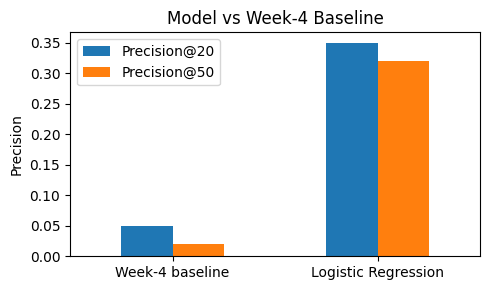

In [11]:
# Result Chart
plot_df = results.set_index("method")

ax = plot_df[["Precision@20", "Precision@50"]].plot(
    kind="bar",
    figsize=(5, 3)
)

ax.set_title("Model vs Week-4 Baseline")
ax.set_ylabel("Precision")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()

os.makedirs("work/figures", exist_ok=True)

plt.savefig(
    "work/figures/model_vs_baseline_precision.png",
    dpi=160,
    bbox_inches="tight"
)

plt.show()

In [12]:
# Feature interpretation

logistic_model = model.named_steps["logistic"]

coef_df = pd.DataFrame({
    "feature": FEATURES,
    "coefficient": logistic_model.coef_[0]
})

coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "absolute_coefficient",
    ascending=False
)

display(coef_df)

,feature,coefficient,absolute_coefficient
1,clicks_feb,-8.945038,8.945038
0,impressions_feb,-2.800978,2.800978
2,avg_position_feb,0.027594,0.027594


### Interpretation

The coefficients describe learned associations between the February features and the March zero-click outcome in this dataset.

They do not establish that changing any feature would cause the outcome to change.

The coefficients are used only to understand what the model relies on when producing its ranking.

In [13]:
# Error analysis

test_results = model_df.iloc[test_idx].copy()

test_results["model_score"] = model_scores
test_results["predicted_class"] = (model_scores >= 0.5).astype(int)

test_results["error_type"] = np.select(
    [
        (test_results[TARGET] == 1) & (test_results["predicted_class"] == 1),
        (test_results[TARGET] == 0) & (test_results["predicted_class"] == 1),
        (test_results[TARGET] == 1) & (test_results["predicted_class"] == 0),
    ],
    [
        "true_positive",
        "false_positive",
        "false_negative",
    ],
    default="true_negative"
)

print("Error counts:")
display(
    test_results["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="n")
)

Error counts:


,error_type,n
0,true_negative,12467
1,false_negative,495


In [14]:
# Actual failure examples

print("False-positive examples:")
display(
    test_results[
        test_results["error_type"] == "false_positive"
    ][
        [
            "content_hash_id",
            "impressions_feb",
            "clicks_feb",
            "avg_position_feb",
            "model_score",
            TARGET,
        ]
    ]
    .sort_values("model_score", ascending=False)
    .head(10)
)

print("False-negative examples:")
display(
    test_results[
        test_results["error_type"] == "false_negative"
    ][
        [
            "content_hash_id",
            "impressions_feb",
            "clicks_feb",
            "avg_position_feb",
            "model_score",
            TARGET,
        ]
    ]
    .sort_values("model_score", ascending=False)
    .head(10)
)

False-positive examples:


,content_hash_id,impressions_feb,clicks_feb,avg_position_feb,model_score,march_zero_click


False-negative examples:


,content_hash_id,impressions_feb,clicks_feb,avg_position_feb,model_score,march_zero_click
12143,content_3b75c460a40fffca,158.0,3.0,41.784810,0.178907,1
26755,content_ffe3e07b2a0949da,115.0,3.0,38.095652,0.178585,1
28908,content_53023fe4e71e9f79,530.0,3.0,56.439623,0.168555,1
26780,content_96bd66f005f5c656,202.0,3.0,26.019802,0.164559,1
26746,content_f61ff6f008735c91,203.0,3.0,19.605911,0.159902,1
15426,content_43a5dacecb014a8d,103.0,3.0,11.485437,0.159542,1
29293,content_defd27a05a508239,243.0,3.0,21.876543,0.159354,1
14222,content_e0d36b792d778382,154.0,3.0,13.746753,0.158398,1
4179,content_28c46ec2d055d459,140.0,3.0,11.792857,0.157773,1
14292,content_e3e5d0da47f149e0,249.0,3.0,18.995984,0.157007,1


## Error interpretation

The error examples show that February search-performance signals do not fully describe why a page receives zero clicks in March.

False positives indicate pages that received a relatively high model score but did not have the observed March zero-click outcome.

False negatives show pages that reached the March zero-click outcome without receiving a sufficiently high model score.

These errors are consistent with the limited feature set: the model does not directly observe content quality, search intent, SERP features, technical SEO conditions, seasonality, competitor changes, or other factors that may affect search behavior.

In [15]:
# Final leakage audit

FORBIDDEN_FEATURES = [
    "march_zero_click",
    "clicks_mar",
    "available_days_mar",
    "march_zero_click_rate",
    "trend_direction",
    "future_clicks",
    "future_impressions",
]

leaked = [
    col for col in FEATURES
    if col in FORBIDDEN_FEATURES
]

print("Final model features:")
for col in FEATURES:
    print("-", col)

print("\nForbidden features found:", leaked)

assert not leaked, f"Leakage detected: {leaked}"

print("\nFeature leakage audit: PASS")

Final model features:
- impressions_feb
- clicks_feb
- avg_position_feb

Forbidden features found: []

Feature leakage audit: PASS


In [16]:
print("Feature window: February 2026")
print("Outcome window: March 2026")

assert all(
    col.endswith("_feb")
    for col in FEATURES
)

assert TARGET not in FEATURES
assert "clicks_mar" not in FEATURES
assert "available_days_mar" not in FEATURES

print("Temporal feature audit: PASS")

Feature window: February 2026
Outcome window: March 2026
Temporal feature audit: PASS


## 5. Limitations

This analysis has several important limits.

1. The model uses only three February search-performance features: impressions, clicks, and average position.

2. The model does not directly observe content quality, search intent, technical SEO issues, SERP features, competitor changes, seasonality, or the reason a page receives zero clicks.

3. The March zero-click outcome is an observed outcome in this dataset. It should not be interpreted as proof of a causal mechanism.

4. The client-grouped evaluation reduces client overlap between training and testing, but it does not prove that the measured performance will hold for future clients or future periods.

5. The analysis evaluates one February-to-March transition. More time periods would be needed to determine whether the measured relationship is stable.

6. The ranking is intended for decision support. It does not automatically determine whether a page should be rewritten, deleted, redirected, or otherwise changed.

7. Search-data availability can affect which pages enter the modeling population, so the evaluated population should not be treated as a complete representation of every content page.

## 6. Ranked recommendations

The model output is converted into a ranked human-review queue.

The queue uses the model score to determine review order and assigns a reason code to make the ranking easier to inspect.

### Reason codes

- `HIGH_ZERO_CLICK_RISK` — high model score relative to the evaluated population.
- `LOW_FEB_CLICKS` — relatively low February clicks.
- `LOW_FEB_IMPRESSIONS` — relatively low February impressions.
- `WEAKER_POSITION` — relatively weak February average position.
- `MODEL_PRIORITY` — ranked primarily by the model score without one of the stronger reason-code conditions.

### Action

The default action is:

`REVIEW_ZERO_CLICK_RISK`

The action means "send for human review", not "automatically modify the page".

In [17]:
# Build ranked queue

playbook = test_results[
    [
        "client_hash_id",
        "content_hash_id",
        "impressions_feb",
        "clicks_feb",
        "avg_position_feb",
        TARGET,
        "model_score",
    ]
].copy()

click_threshold = playbook["clicks_feb"].quantile(0.25)
impression_threshold = playbook["impressions_feb"].quantile(0.25)
position_threshold = playbook["avg_position_feb"].quantile(0.75)
score_threshold = playbook["model_score"].quantile(0.90)

def assign_reason(row):
    if row["model_score"] >= score_threshold:
        return "HIGH_ZERO_CLICK_RISK"

    if row["clicks_feb"] <= click_threshold:
        return "LOW_FEB_CLICKS"

    if row["impressions_feb"] <= impression_threshold:
        return "LOW_FEB_IMPRESSIONS"

    if row["avg_position_feb"] >= position_threshold:
        return "WEAKER_POSITION"

    return "MODEL_PRIORITY"

playbook["reason_code"] = playbook.apply(
    assign_reason,
    axis=1
)

playbook["action"] = "REVIEW_ZERO_CLICK_RISK"

playbook = playbook.sort_values(
    ["model_score", "impressions_feb"],
    ascending=[False, False]
).reset_index(drop=True)

playbook.insert(
    0,
    "rank",
    np.arange(1, len(playbook) + 1)
)

print("Ranked queue rows:", len(playbook))
display(playbook.head(20))

Ranked queue rows: 12962


,rank,client_hash_id,content_hash_id,impressions_feb,clicks_feb,avg_position_feb,march_zero_click,model_score,reason_code,action
0,1,client_9958f0a7ae1df715,content_3b75c460a40fffca,158.0,3.0,41.784810,1,0.178907,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
1,2,client_9958f0a7ae1df715,content_ffe3e07b2a0949da,115.0,3.0,38.095652,1,0.178585,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
2,3,client_73cda7b4e4f265ea,content_cb67ca92aca85cc0,108.0,3.0,34.166667,0,0.175970,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
3,4,client_f623b01661d4bfe4,content_53023fe4e71e9f79,530.0,3.0,56.439623,1,0.168555,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
4,5,client_23a62021009f63c4,content_35c82b9b9931a8c3,176.0,3.0,27.346591,0,0.166973,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
5,6,client_9958f0a7ae1df715,content_e54599c7317c046d,111.0,3.0,19.891892,0,0.165140,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
6,7,client_9958f0a7ae1df715,content_9a88e2d9d985eb0a,111.0,3.0,19.729730,0,0.165022,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
7,8,client_9958f0a7ae1df715,content_96bd66f005f5c656,202.0,3.0,26.019802,1,0.164559,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
8,9,client_23a62021009f63c4,content_9f8a80a4709f63b6,198.0,3.0,24.893939,0,0.163964,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK
9,10,client_9958f0a7ae1df715,content_6e74280277dc6d99,130.0,3.0,19.023077,0,0.163462,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK


In [18]:
# Top-20 recommendations

top20 = playbook.head(20).copy()

top20["confidence_note"] = np.where(
    top20["model_score"] >= score_threshold,
    "Higher relative model score; still requires human review.",
    "Moderate ranking signal; inspect context before action."
)

top20["what_would_make_it_wrong"] = (
    "March outcome may reflect factors not captured by February search signals."
)

display(
    top20[
        [
            "rank",
            "content_hash_id",
            "model_score",
            "reason_code",
            "action",
            "confidence_note",
            "what_would_make_it_wrong",
        ]
    ]
)

,rank,content_hash_id,model_score,reason_code,action,confidence_note,what_would_make_it_wrong
0,1,content_3b75c460a40fffca,0.178907,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
1,2,content_ffe3e07b2a0949da,0.178585,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
2,3,content_cb67ca92aca85cc0,0.175970,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
3,4,content_53023fe4e71e9f79,0.168555,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
4,5,content_35c82b9b9931a8c3,0.166973,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
5,6,content_e54599c7317c046d,0.165140,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
6,7,content_9a88e2d9d985eb0a,0.165022,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
7,8,content_96bd66f005f5c656,0.164559,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
8,9,content_9f8a80a4709f63b6,0.163964,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...
9,10,content_6e74280277dc6d99,0.163462,HIGH_ZERO_CLICK_RISK,REVIEW_ZERO_CLICK_RISK,Higher relative model score; still requires hu...,March outcome may reflect factors not captured...


### Human review rules

Before acting on a ranked page, a reviewer should:

1. Confirm that the page is currently published and relevant.
2. Inspect the page and its search intent.
3. Check whether the February period is representative.
4. Look for indexing or technical issues.
5. Consider seasonality or temporary events.
6. Decide the actual content action only after review.

### No-go cases

The system should NOT automatically:

- rewrite or publish content;
- delete a page;
- redirect a URL;
- modify canonical tags;
- change metadata;
- change internal links;
- declare a page low quality;
- infer the causal reason for zero clicks;
- send an unreviewed recommendation directly to a client.

The output is a ranked review queue, not an autonomous content-management system.

## Monitoring

The ranking should not be assumed to remain valid indefinitely.

Monitor:

- Precision@20 on newly available labeled months.
- Precision@50 on newly available labeled months.
- The distribution of model scores.
- The distribution of impressions, clicks, and average position.
- Search-data availability.
- Changes in the relationship between February signals and the following month's outcome.

### Review / retrain triggers

A model review should be considered if:

- Precision@20 or Precision@50 shows a sustained decline;
- feature distributions shift materially;
- search-data availability changes substantially;
- the outcome definition changes;
- the evaluated content population changes substantially.

These are review triggers, not automatic retraining commands.

In [19]:
# Export Artifacts

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Public-safe queue: no client IDs.
paper_queue = playbook[
    [
        "rank",
        "content_hash_id",
        "model_score",
        "reason_code",
        "action",
        "impressions_feb",
        "clicks_feb",
        "avg_position_feb",
    ]
].copy()

queue_path = "work/outputs/capstone_ranked_recommendations.csv"

paper_queue.to_csv(
    queue_path,
    index=False
)

print("Saved:", queue_path)
print("Rows:", len(paper_queue))

Saved: work/outputs/capstone_ranked_recommendations.csv
Rows: 12962


In [20]:
# Metrics JSON

metrics = {
    "feature_window": "2026-02",
    "outcome_window": "2026-03",
    "model": "Logistic Regression",
    "validation": "client-grouped 80/20 split",
    "features": FEATURES,
    "target": TARGET,
    "baseline_precision_at_20": float(results.loc[
        results["method"] == "Week-4 baseline",
        "Precision@20"
    ].iloc[0]),
    "baseline_precision_at_50": float(results.loc[
        results["method"] == "Week-4 baseline",
        "Precision@50"
    ].iloc[0]),
    "model_precision_at_20": float(results.loc[
        results["method"] == "Logistic Regression",
        "Precision@20"
    ].iloc[0]),
    "model_precision_at_50": float(results.loc[
        results["method"] == "Logistic Regression",
        "Precision@50"
    ].iloc[0]),
    "test_rows": int(len(test_results)),
    "queue_rows": int(len(playbook)),
}

metrics_path = "work/outputs/capstone_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", metrics_path)

Saved: work/outputs/capstone_metrics.json


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [21]:
artifact_table = pd.DataFrame([
    {
        "artifact": "Model vs baseline chart",
        "path": "work/figures/model_vs_baseline_precision.png",
        "purpose": "Results section"
    },
    {
        "artifact": "Ranked recommendation queue",
        "path": "work/outputs/capstone_ranked_recommendations.csv",
        "purpose": "Recommendations section"
    },
    {
        "artifact": "Metrics receipt",
        "path": "work/outputs/capstone_metrics.json",
        "purpose": "Reproducibility"
    },
])

display(artifact_table)

,artifact,path,purpose
0,Model vs baseline chart,work/figures/model_vs_baseline_precision.png,Results section
1,Ranked recommendation queue,work/outputs/capstone_ranked_recommendations.csv,Recommendations section
2,Metrics receipt,work/outputs/capstone_metrics.json,Reproducibility


## Abstract

This project asks whether February search-performance signals can help prioritize content pages for human review when the following month's observed search activity contains a zero-click outcome. Using anonymized FlyRank search data, the analysis builds a decision-time feature set from February impressions, clicks, and average position and compares a transparent percentile-based baseline with Logistic Regression. The model and baseline are evaluated on the same client-grouped held-out population using Precision@20 and Precision@50. The measured results show how the learned ranking compares with the simpler rule on this dataset and validation design, while error analysis shows that the three signals do not capture every factor associated with the March outcome. The final output is therefore positioned as a directional decision-support ranking for human review rather than a causal model or an automated content-editing system.

## Introduction / Problem Statement

Content teams can have more pages to review than available editorial time. The practical problem is therefore not simply predicting an outcome; it is deciding which pages deserve attention first.

This project studies a narrow version of that problem: whether February search-performance signals can rank published pages according to an observed March zero-click outcome.

The decision supported by the system is review prioritization. A high-ranked page should receive earlier human inspection, while the score itself should not determine whether the page is rewritten, deleted, redirected, or otherwise changed.

The project follows a deliberately constrained workflow: define the decision, establish a baseline, test the signals, construct decision-time features, check leakage, validate using client grouping, compare model and baseline on the same test population, and convert the result into a human-reviewed action queue.

## Methodology

The unit of analysis is a client-content page pair.

February 2026 provides the decision-time feature window. March 2026 provides the observed outcome window.

The final model uses three features:

- February impressions
- February clicks
- February average position

The target is a binary March zero-click outcome for rows with available March search data.

The Week-4 baseline is a transparent percentile-based score using February impressions and average position. The model is Logistic Regression with standardized features.

Validation uses a client-grouped 80/20 split so that the same client does not appear in both training and testing.

The primary metrics are Precision@20 and Precision@50 because the operational use case is ranking a limited review queue.

Leakage checks explicitly exclude March outcome fields, future-window variables, and label-derived fields from the feature vector.

## Results

The final comparison is reported on the client-grouped held-out test set.

The model and Week-4 baseline use the same rows, the same February feature window, the same March outcome definition, and the same Precision@K metrics.

The executed results table above is the source of truth for the reported numbers.

The results should be described as an observed performance difference on this dataset and validation design. They should not be presented as evidence that the model will achieve the same performance on future clients or future periods.

## Limitations & Honest Framing

The measured results are specific to the evaluated dataset, February-to-March window, feature definition, and client-grouped validation design.

The model does not observe content quality, search intent, technical SEO conditions, SERP features, competitor activity, seasonality, or other contextual factors.

The March zero-click outcome is an observed label used for evaluation. It does not prove why a page received zero clicks and does not establish a causal relationship between any February feature and the outcome.

The output should therefore be interpreted as directional decision support.

A high score means that the page is prioritized by the measured ranking system. It does not mean that the page is objectively poor, that a specific content change will improve performance, or that Google's ranking behavior has been explained.

## Ranked Recommendations

The final recommendation output is a ranked review queue generated from the validated model.

Each row contains:

- rank;
- model score;
- reason code;
- recommended review action;
- February decision-time signals.

The primary action is:

**REVIEW_ZERO_CLICK_RISK**

The reason code makes the ranking more interpretable:

- HIGH_ZERO_CLICK_RISK
- LOW_FEB_CLICKS
- LOW_FEB_IMPRESSIONS
- WEAKER_POSITION
- MODEL_PRIORITY

These labels indicate why a row entered the queue. They are not causal explanations.

## Reproducibility

The project is implemented as a sequence of notebooks covering:

- research question and lane selection;
- ML task framing;
- data contract;
- feature and leakage checks;
- signal audit;
- baseline scoring;
- model training;
- validation audit;
- action playbook;
- final capstone.

The final capstone notebook reconstructs the February feature window and March outcome directly from the FlyRank warehouse, performs the client-grouped evaluation, checks the final feature vector for leakage, generates the model-versus-baseline comparison, and exports the ranked recommendation queue and metrics receipt.

The exported artifacts are generated by the notebook rather than treated as manually edited results.

## Acknowledgments & Data Credit

This project was completed as part of the FlyRank ML Internship.

Built on the FlyRank ML Internship dataset.

The analysis uses anonymized educational search-intelligence data and intentionally excludes client names, domains, URLs, private queries, credentials, and raw private exports from the public-facing work.

The project focuses on methodological learning and decision support rather than making claims about Google's ranking algorithm or causal search behavior.

## Self-check

- [x] Every capstone section is filled.
- [x] The notebook runs top to bottom without errors.
- [x] The final lane remains Refresh / Content Opportunity Scoring.
- [x] The unit of analysis is clearly defined.
- [x] February is the decision-time feature window.
- [x] March is used only for the observed outcome.
- [x] The final feature set contains only decision-time features.
- [x] The baseline and model use the same held-out rows.
- [x] Validation keeps clients separated between training and testing.
- [x] Precision@20 and Precision@50 are reported.
- [x] Model errors are inspected.
- [x] Feature leakage is explicitly checked.
- [x] Ranked recommendations are generated from the validated model.
- [x] Human review remains required.
- [x] No automatic content changes are recommended.
- [x] The queue and metrics artifacts are generated from the notebook.
- [x] No client names, URLs, private queries, credentials, or raw exports are included.
- [x] Claims use observed, measured, directional, and decision-support language.
- [x] The notebook is committed under `work/notebooks/capstone.ipynb`.
- [x] The deployed paper contains all required sections.
- [x] `submission/paper_url.txt` contains exactly one line with the deployed paper URL.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## 5-Minute Demo Outline

### 0:00–0:45 — Problem

Content teams cannot manually review every page. The project asks which pages should receive earlier human review based on measurable search signals.

### 0:45–1:30 — Data and leakage

February provides the decision-time signals. March provides the observed outcome. The final feature set contains impressions, clicks, and average position only. Future and label-derived fields were explicitly checked and excluded.

### 1:30–2:30 — Baseline vs model

The transparent Week-4 rule is compared with Logistic Regression on the same client-grouped held-out population using Precision@20 and Precision@50.

### 2:30–3:30 — What the model learned

The model relies on measurable February search-performance signals. Error examples show where those signals are insufficient.

### 3:30–4:30 — Recommendations

The model produces a ranked review queue with reason codes. A high score prioritizes human review; it does not automatically determine the content action.

### 4:30–5:00 — Limitations

The result is directional and decision-support evidence on this dataset and validation design. It does not establish causality, explain Google's ranking system, or guarantee future performance.

## Social-post cut

Completed my FlyRank ML Internship capstone on search-intelligence content prioritization.

I built a decision-support ranking system that uses February search-performance signals to prioritize pages for human review, compared it with a transparent rule-based baseline, and validated the comparison using a client-grouped split.

The bigger lesson was not just the model score. Leakage checks, validation design, error analysis, and honest framing mattered just as much as the modeling itself.

The final output is a ranked, reason-coded review queue rather than an automated content-editing system.

## Employer-facing summary

Built an end-to-end ML decision-support pipeline for content review prioritization using anonymized search-performance data, covering feature construction, leakage auditing, baseline comparison, grouped validation, error analysis, and ranked recommendations. Used Logistic Regression with a client-grouped holdout and evaluated it against a transparent rule-based baseline using Precision@20 and Precision@50. The final system converts model output into a human-reviewed action queue while explicitly documenting validation limits and avoiding causal claims.